# European Digital Readiness Index (EDRI)
# Data Analysis and Visualisation CA1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Loading Dataset

In [6]:
from pathlib import Path

notebook_dir = Path.cwd()
data_path = notebook_dir.parent / "Data" / "edri_data.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at {data_path}")

print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)

print("Original dataset:")
print(df.head())

Loading dataset from: c:\Users\eljes\OneDrive - Dundalk Institute of Technology\Desktop\DAV_CA_ELJESA\Data\edri_data.csv
Original dataset:
                  Country  Internet_Access  Digital_Skills  EGovernment_Use  \
0                 Austria            94.96           64.68            64.05   
1                 Belgium            94.62           59.39            67.40   
2  Bosnia and Herzegovina            84.19           30.08            21.62   
3                Bulgaria            92.12           35.52            24.54   
4                 Croatia            88.37           58.95            44.53   

   Cloud_Computing  
0             35.6  
1             47.7  
2             18.1  
3             14.2  
4             40.7  


# Checking dataset structure


In [7]:
print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include='all'))

print("\nMissing values before imputation:")
print(df.isnull().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          32 non-null     object 
 1   Internet_Access  32 non-null     float64
 2   Digital_Skills   32 non-null     float64
 3   EGovernment_Use  32 non-null     float64
 4   Cloud_Computing  32 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.4+ KB

Summary statistics:


,Country,Internet_Access,Digital_Skills,EGovernment_Use,Cloud_Computing
count,32,32.000000,32.000000,32.000000,32.000000
unique,32,NaN,NaN,NaN,NaN
top,Austria,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,93.440625,55.806875,61.668750,39.278125
std,NaN,3.772175,14.563900,20.430486,16.676558
min,NaN,84.190000,27.730000,18.200000,14.200000
25%,NaN,91.740000,46.462500,45.740000,28.300000
50%,NaN,94.500000,57.430000,64.815000,35.800000
75%,NaN,95.657500,65.055000,75.700000,52.725000



Missing values before imputation:
Country            0
Internet_Access    0
Digital_Skills     0
EGovernment_Use    0
Cloud_Computing    0
dtype: int64


# Imputation of missing data

In [8]:
indicator_columns = [
    "Internet_Access",
    "Digital_Skills",
    "EGovernment_Use",
    "Cloud_Computing"
]

for col in indicator_columns:
    df[col] = df[col].fillna(df[col].mean())

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Country            0
Internet_Access    0
Digital_Skills     0
EGovernment_Use    0
Cloud_Computing    0
dtype: int64


#  Correlation analysis


Correlation matrix:
                 Internet_Access  Digital_Skills  EGovernment_Use  \
Internet_Access         1.000000        0.481076         0.634726   
Digital_Skills          0.481076        1.000000         0.757191   
EGovernment_Use         0.634726        0.757191         1.000000   
Cloud_Computing         0.478528        0.729527         0.632529   

                 Cloud_Computing  
Internet_Access         0.478528  
Digital_Skills          0.729527  
EGovernment_Use         0.632529  
Cloud_Computing         1.000000  


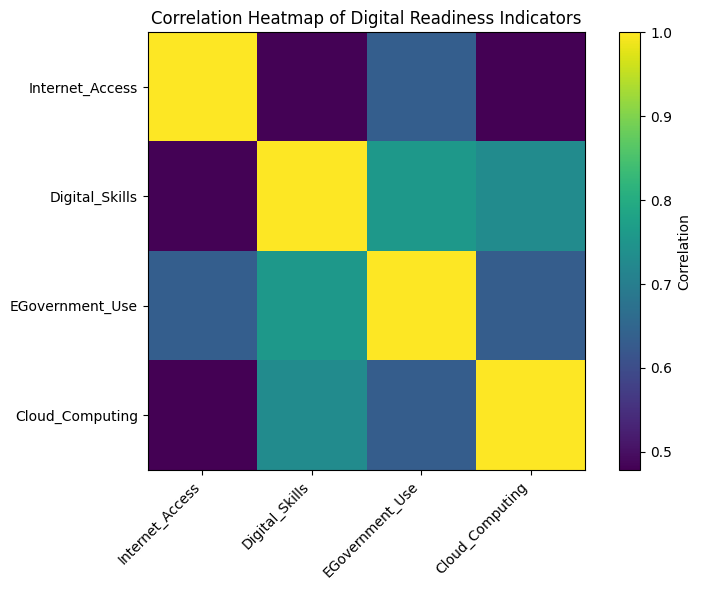

In [ ]:
correlation_matrix = df[indicator_columns].corr()

print("\nCorrelation matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(indicator_columns)), indicator_columns, rotation=45, ha="right")
plt.yticks(range(len(indicator_columns)), indicator_columns)
plt.title("Correlation Heatmap of Digital Readiness Indicators")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()


#  Normalisation

In [10]:
scaler = MinMaxScaler(feature_range=(0, 100))
normalised_values = scaler.fit_transform(df[indicator_columns])

normalised_df = pd.DataFrame(
    normalised_values,
    columns=[col + "_Norm" for col in indicator_columns]
)

df = pd.concat([df, normalised_df], axis=1)

print("\nNormalised data:")
print(df[["Country"] + list(normalised_df.columns)].head())



Normalised data:
                  Country  Internet_Access_Norm  Digital_Skills_Norm  \
0                 Austria             72.525253            67.218483   
1                 Belgium             70.235690            57.595052   
2  Bosnia and Herzegovina              0.000000             4.275059   
3                Bulgaria             53.400673            14.171366   
4                 Croatia             28.148148            56.794615   

   EGovernment_Use_Norm  Cloud_Computing_Norm  
0             59.599636             36.394558  
1             63.954244             56.972789  
2              4.445600              6.632653  
3              8.241258              0.000000  
4             34.225920             45.068027  


# Weighting and aggregation

Equal weighting is used:
Connectivity = 25%
Digital Skills = 25%
E-Government = 25%
Business Digitalisation = 25%

In [11]:
df["Connectivity_SubIndex"] = df["Internet_Access_Norm"]
df["DigitalSkills_SubIndex"] = df["Digital_Skills_Norm"]
df["EGovernment_SubIndex"] = df["EGovernment_Use_Norm"]
df["BusinessDigitalisation_SubIndex"] = df["Cloud_Computing_Norm"]

df["EDRI_Score"] = (
    0.25 * df["Connectivity_SubIndex"] +
    0.25 * df["DigitalSkills_SubIndex"] +
    0.25 * df["EGovernment_SubIndex"] +
    0.25 * df["BusinessDigitalisation_SubIndex"]
)

## Rank countries from highest to lowest score

In [12]:
df["Rank"] = df["EDRI_Score"].rank(ascending=False, method="min").astype(int)
df = df.sort_values(by="EDRI_Score", ascending=False)

print("\nFinal EDRI ranking:")
print(df[["Rank", "Country", "EDRI_Score"]])


Final EDRI ranking:
    Rank                 Country  EDRI_Score
9      1                 Finland   95.070637
22     2                  Norway   94.097614
21     3             Netherlands   90.254127
7      4                 Denmark   87.591121
30     5                  Sweden   78.438379
14     6                 Ireland   71.882780
8      7                 Estonia   67.297584
19     8                   Malta   67.056567
18     9              Luxembourg   65.539117
1     10                 Belgium   62.189444
13    11                 Hungary   60.899569
6     12                 Czechia   60.394973
5     13                  Cyprus   59.270838
0     14                 Austria   58.934482
29    15                   Spain   58.502461
10    16                  France   52.762194
28    17                Slovenia   49.682793
23    18                  Poland   49.096660
15    19                   Italy   48.818277
17    20               Lithuania   46.658637
16    21                  Latvia  

#  PCA multivariate analysis
Standardisation is used before PCA because PCA is affected by scale.



PCA explained variance ratio:
PC1: 0.7171
PC2: 0.1495
PC3: 0.0851
PC4: 0.0483


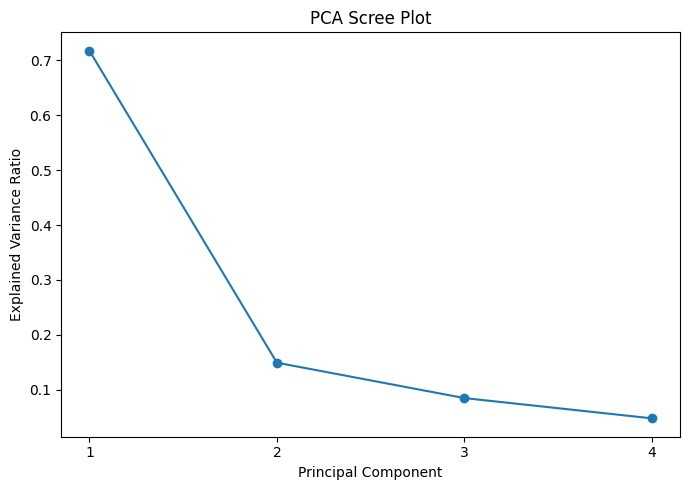

In [13]:
standard_scaler = StandardScaler()
scaled_data = standard_scaler.fit_transform(df[indicator_columns])

pca = PCA()
pca_result = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_

print("\nPCA explained variance ratio:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(range(1, len(explained_variance) + 1))
plt.tight_layout()
plt.savefig("pca_scree_plot.png", dpi=300)
plt.show()

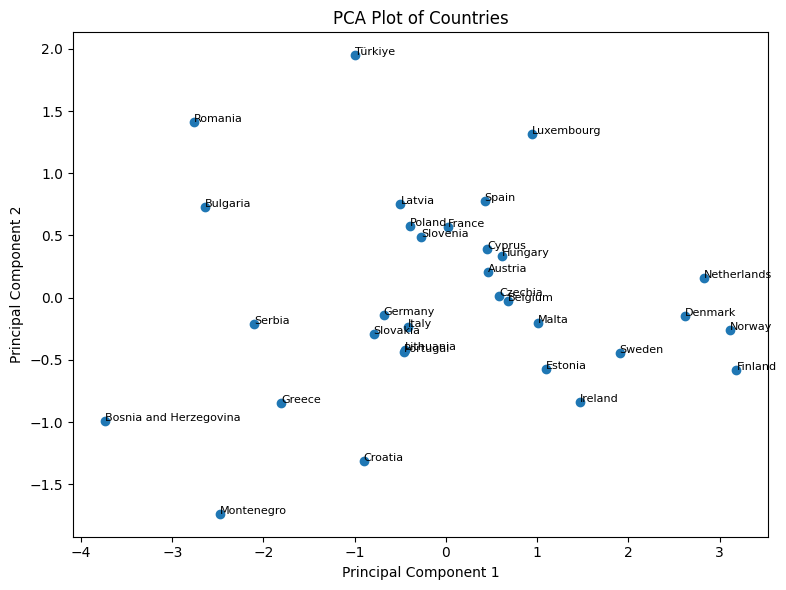

In [14]:
if pca_result.shape[1] >= 2:
    df["PC1"] = pca_result[:, 0]
    df["PC2"] = pca_result[:, 1]

    plt.figure(figsize=(8, 6))
    plt.scatter(df["PC1"], df["PC2"])
    for i, country in enumerate(df["Country"]):
        plt.annotate(country, (df["PC1"].iloc[i], df["PC2"].iloc[i]), fontsize=8)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA Plot of Countries")
    plt.tight_layout()
    plt.savefig("pca_country_plot.png", dpi=300)
    plt.show()

 # Clustering analysis

 K-means clustering is used to group countries with similar digital readiness profiles.

In [15]:
cluster_data = df[[
    "Connectivity_SubIndex",
    "DigitalSkills_SubIndex",
    "EGovernment_SubIndex",
    "BusinessDigitalisation_SubIndex"
]]

silhouette_scores = {}
for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(cluster_data)
    score = silhouette_score(cluster_data, labels_temp)
    silhouette_scores[k] = score

print("\nSilhouette scores:")
for k, score in silhouette_scores.items():
    print(f"k={k}: {score:.4f}")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(cluster_data)

# Label clusters based on average EDRI score
cluster_means = df.groupby("Cluster")["EDRI_Score"].mean().sort_values(ascending=False)
cluster_labels = {}
labels = ["High Digital Readiness", "Medium Digital Readiness", "Low Digital Readiness"]

for label, cluster_id in zip(labels, cluster_means.index):
    cluster_labels[cluster_id] = label

df["Cluster_Label"] = df["Cluster"].map(cluster_labels)

print("\nCountries by cluster:")
print(df[["Country", "EDRI_Score", "Cluster_Label"]].sort_values(by="EDRI_Score", ascending=False))


Silhouette scores:
k=2: 0.3255
k=3: 0.3498
k=4: 0.2933
k=5: 0.2846
k=6: 0.2838

Countries by cluster:
                   Country  EDRI_Score             Cluster_Label
9                  Finland   95.070637    High Digital Readiness
22                  Norway   94.097614    High Digital Readiness
21             Netherlands   90.254127    High Digital Readiness
7                  Denmark   87.591121    High Digital Readiness
30                  Sweden   78.438379    High Digital Readiness
14                 Ireland   71.882780    High Digital Readiness
8                  Estonia   67.297584    High Digital Readiness
19                   Malta   67.056567    High Digital Readiness
18              Luxembourg   65.539117  Medium Digital Readiness
1                  Belgium   62.189444  Medium Digital Readiness
13                 Hungary   60.899569  Medium Digital Readiness
6                  Czechia   60.394973  Medium Digital Readiness
5                   Cyprus   59.270838  Medium Digit

#  Visualisation of final results

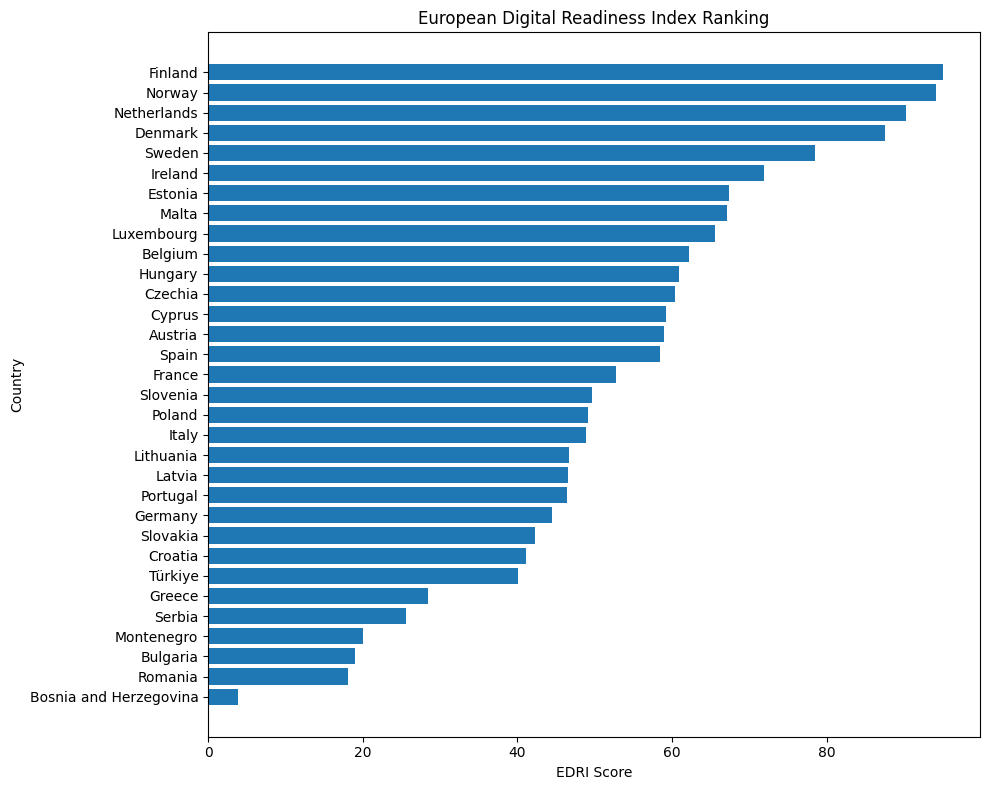

In [16]:
plt.figure(figsize=(10, 8))
plt.barh(df["Country"], df["EDRI_Score"])
plt.xlabel("EDRI Score")
plt.ylabel("Country")
plt.title("European Digital Readiness Index Ranking")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("edri_country_ranking.png", dpi=300)
plt.show()

# Sub-index comparison for top 10 countries

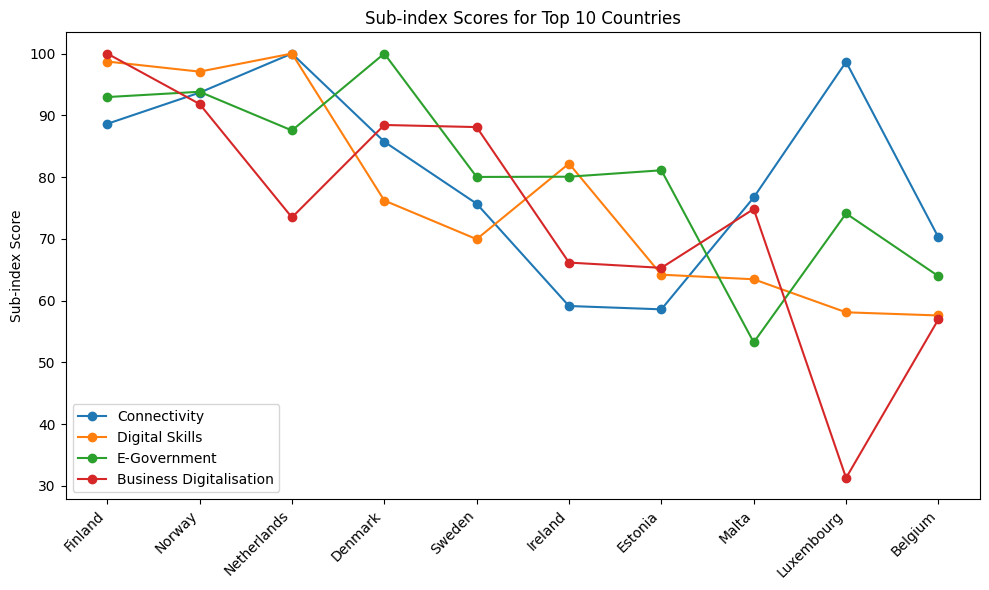

In [17]:
top_10 = df.head(10)

plt.figure(figsize=(10, 6))
plt.plot(top_10["Country"], top_10["Connectivity_SubIndex"], marker="o", label="Connectivity")
plt.plot(top_10["Country"], top_10["DigitalSkills_SubIndex"], marker="o", label="Digital Skills")
plt.plot(top_10["Country"], top_10["EGovernment_SubIndex"], marker="o", label="E-Government")
plt.plot(top_10["Country"], top_10["BusinessDigitalisation_SubIndex"], marker="o", label="Business Digitalisation")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Sub-index Score")
plt.title("Sub-index Scores for Top 10 Countries")
plt.legend()
plt.tight_layout()
plt.savefig("top_10_subindices.png", dpi=300)
plt.show()

# Cluster visualisation using PCA axes

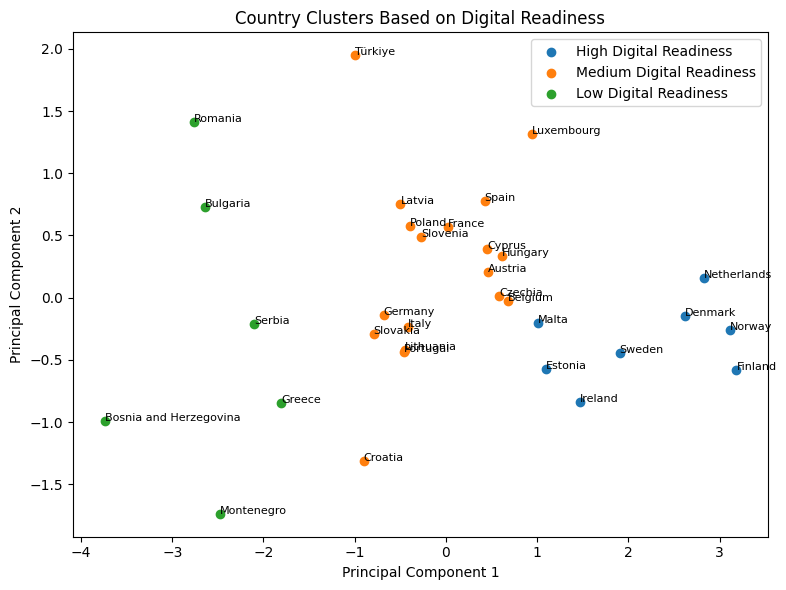

In [18]:
if "PC1" in df.columns and "PC2" in df.columns:
    plt.figure(figsize=(8, 6))
    for cluster_label in df["Cluster_Label"].unique():
        subset = df[df["Cluster_Label"] == cluster_label]
        plt.scatter(subset["PC1"], subset["PC2"], label=cluster_label)

    for i, country in enumerate(df["Country"]):
        plt.annotate(country, (df["PC1"].iloc[i], df["PC2"].iloc[i]), fontsize=8)

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("Country Clusters Based on Digital Readiness")
    plt.legend()
    plt.tight_layout()
    plt.savefig("country_clusters.png", dpi=300)
    plt.show()

In [19]:
df.to_csv("edri_final_results.csv", index=False)
